*This notebook is kept as a record of the exploration phase. The compiled results of the project are in `04_report.ipynb`.*

# Chest Press vs Shoulder Press vs Lateral Raise: IMU pattern comparison

**Goal.** We want to find, from a wrist worn IMU, which signal patterns tell
**Chest Press (rack)**, **Squat Rack Shoulder Press**, and **Lateral Raise** apart.
We look at this before training any classifier, so we know which features are
actually worth using.

We compare three approaches, labeled throughout:

* **OURS (naive)**: the simplest possible features, no correction for how the
  sensor happens to be worn.
* **LITERATURE**: what the RecoFit paper (Morris et al., CHI 2014) actually does,
  PCA, RMS, and autocorrelation based tempo.
* **OURS, UNIQUE**: something the RecoFit paper does not do. We add a gravity
  based tilt correction and test whether it helps.

One honesty note up front. You cannot recover a real trajectory (position,
distance) from an accelerometer. Double integration drifts within seconds. We
don't pretend otherwise. Section 10 measures exactly how bad that drift is.

**Data.** `data/recordings.csv` (99 sets, one row each) and `data/samples.csv`
(232,046 raw sensor rows, 50 Hz, right arm sensor only).

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.integrate import cumulative_trapezoid

DATA_DIR = "../data"
recordings = pd.read_csv(f"{DATA_DIR}/recordings.csv")
samples = pd.read_csv(f"{DATA_DIR}/samples.csv")

BENCH = "Chest Press (rack)"
SHOULDER = "Squat Rack Shoulder Press"
LATERAL = "Lateral Raise"
EXERCISES = [BENCH, SHOULDER, LATERAL]
ACC = ["accel_x_g", "accel_y_g", "accel_z_g"]
GYR = ["gyro_x_dps", "gyro_y_dps", "gyro_z_dps"]

def tidy_xticks(ax):
    ax.tick_params(axis="x", labelrotation=10)

print(f"recordings: {recordings.shape}, samples: {samples.shape}")

# show full tables in this notebook, no "..." truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

TABLES_DIR = "../outputs"
os.makedirs(TABLES_DIR, exist_ok=True)


recordings: (99, 8), samples: (232046, 10)


## 1. What data do we actually have

Before touching any feature, we should know how much data backs it up. Too few
sets or subjects means any pattern we find could just be noise.

The table below shows, per exercise: how many sets were recorded, how many
different people did them, and how many reps in total. `incomplete_data` is a flag
that comes with the dataset itself, we report it, we don't remove those rows.

In [2]:
print("Sets per exercise:")
print(recordings["activity_name"].value_counts())

summary = recordings.groupby("activity_name").agg(
    n_sets=("record_uid", "count"),
    n_subjects=("subject_id", "nunique"),
    total_reps=("activity_reps", "sum"),
).reset_index()
summary["sets_per_subject_avg"] = (summary["n_sets"] / summary["n_subjects"]).round(2)
summary["reps_per_subject_avg"] = (summary["total_reps"] / summary["n_subjects"]).round(2)
summary["reps_per_set_avg"] = (summary["total_reps"] / summary["n_sets"]).round(2)

print("\nSubjects, sets and reps per exercise:")
display(summary)

n_incomplete = (recordings["incomplete_data"] == 1).sum()
print(f"\n{n_incomplete} of {len(recordings)} records are flagged incomplete_data=1 "
      f"(kept, not filtered out):")
if n_incomplete:
    display(recordings.loc[recordings["incomplete_data"] == 1,
                            ["record_uid", "activity_name", "subject_id", "activity_reps"]])

Sets per exercise:
activity_name
Lateral Raise                35
Squat Rack Shoulder Press    33
Chest Press (rack)           31
Name: count, dtype: int64

Subjects, sets and reps per exercise:


,activity_name,n_sets,n_subjects,total_reps,sets_per_subject_avg,reps_per_subject_avg,reps_per_set_avg
0,Chest Press (rack),31,21,495,1.48,23.57,15.97
1,Lateral Raise,35,30,504,1.17,16.80,14.40
2,Squat Rack Shoulder Press,33,29,505,1.14,17.41,15.30



2 of 99 records are flagged incomplete_data=1 (kept, not filtered out):


,record_uid,activity_name,subject_id,activity_reps
36,singleonly_subject033_Squat_Rack_Shoulder_Press_record0001,Squat Rack Shoulder Press,502,15
68,singleonly_subject033_Lateral_Raise_record0001,Lateral Raise,502,15


## 2. How we're organizing this

Two questions get asked separately in every section below, and they should not be
mixed up.

First, which signal do we even look at. The sensor can be worn at any angle, so
"raw x axis" doesn't mean the same thing across recordings. We test three ways to
fix that: use the raw axes as they are (naive), project them with PCA (what
RecoFit does), or rotate them using an estimate of gravity (our own addition).

Second, once we have a signal we trust, what number do we pull out of it. We
compute energy (RMS) and tempo (autocorrelation) the same way on top of all three
signal choices above.

So "correcting for orientation" and "computing energy or tempo" are two separate
steps, not the same thing. Section 11, near the end, puts every resulting feature
into one table and ranks them by how well they separate two hard pairs of
exercises. That table is what the conclusion in section 12 is based on, nothing in
this notebook is claimed without a number behind it.

## 3. What the raw signal looks like

`sqrt(x^2 + y^2 + z^2)` throws away direction and only keeps intensity, so we use
it as a baseline. Looking at each axis separately keeps direction, and that's
where we expect the real difference between exercises to show up: does the same
axis dominate for all three, or does it change?

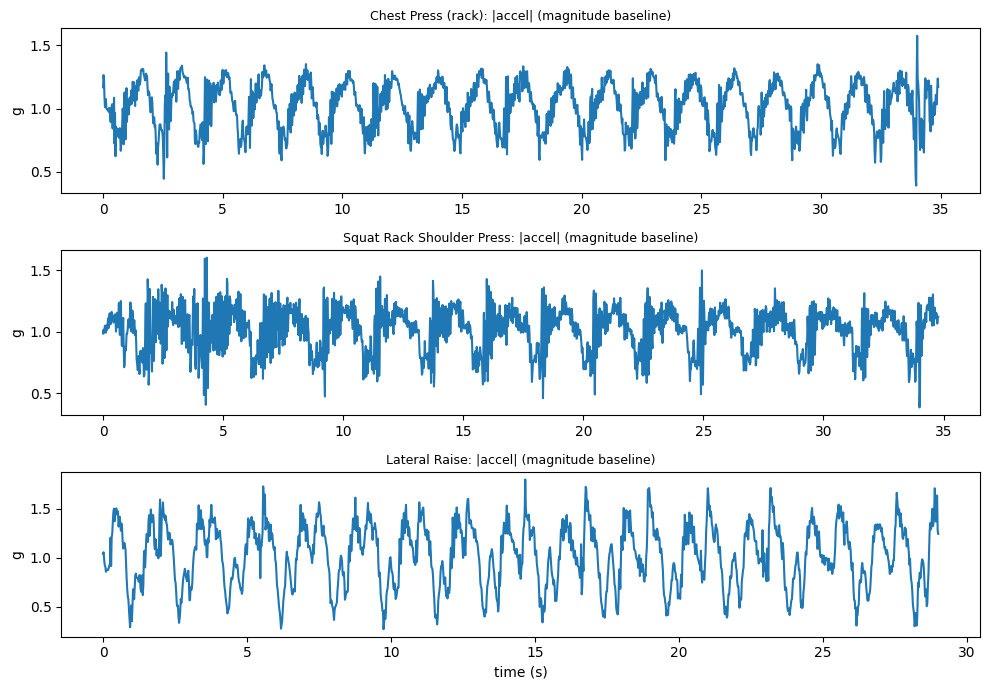

In [3]:
def load_signal(record_uid):
    rec = samples[samples["record_uid"] == record_uid].sort_values("sample_index")
    return rec

recordings_by_exercise = {ex: recordings[recordings["activity_name"] == ex] for ex in EXERCISES}
# pick one clean example set per exercise (at least 15 reps) to plot below
example_uid = {}
for ex in EXERCISES:
    cand = recordings_by_exercise[ex]
    cand_ok = cand[cand["activity_reps"] >= 15]
    example_uid[ex] = (cand_ok.iloc[0] if len(cand_ok) else cand.iloc[0])["record_uid"]

example_signal = {ex: load_signal(uid) for ex, uid in example_uid.items()}

fig, axes = plt.subplots(len(EXERCISES), 1, figsize=(10, 7))
for ax, ex in zip(axes, EXERCISES):
    sig = example_signal[ex]
    mag = np.sqrt((sig[ACC] ** 2).sum(axis=1))
    ax.plot(sig["time_s"] - sig["time_s"].iloc[0], mag)
    ax.set_title(f"{ex}: |accel| (magnitude baseline)", fontsize=9)
    ax.set_ylabel("g")
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

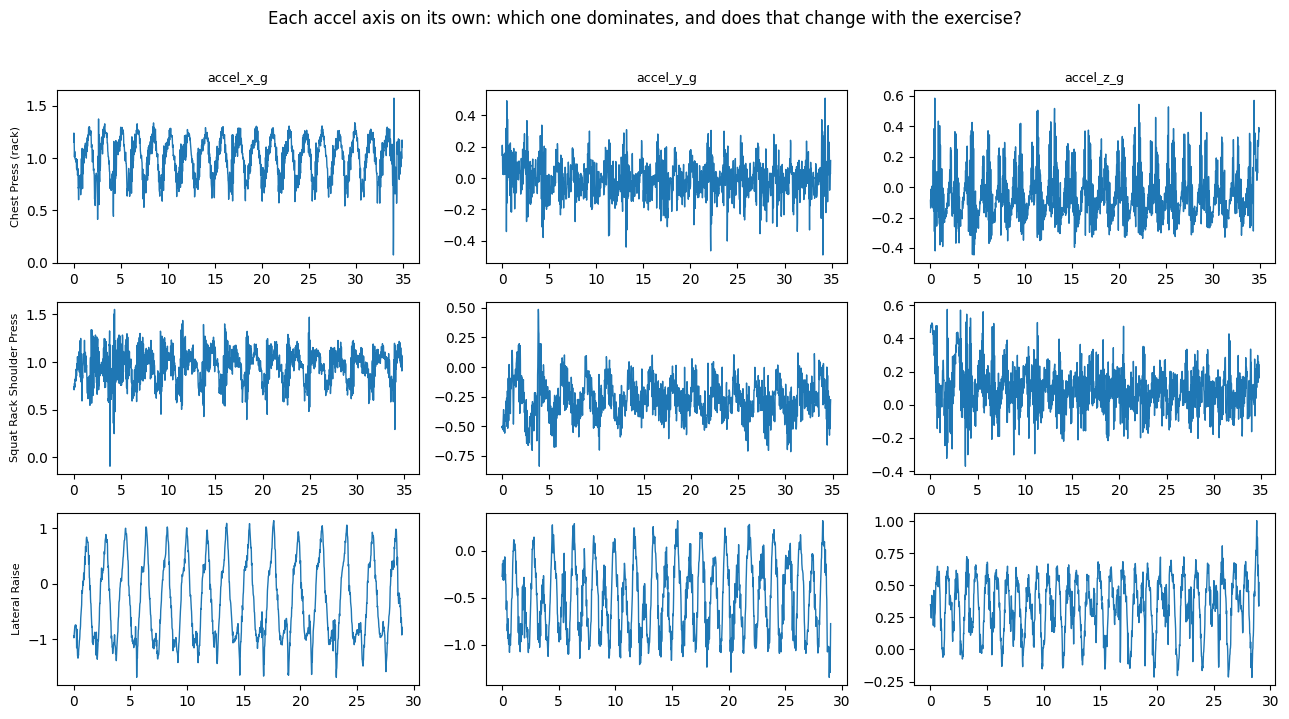

In [4]:
fig, axes = plt.subplots(len(EXERCISES), 3, figsize=(13, 7), sharex=False)
for row, ex in enumerate(EXERCISES):
    sig = example_signal[ex]
    t = sig["time_s"].to_numpy() - sig["time_s"].iloc[0]
    for col, axis_col in enumerate(ACC):
        ax = axes[row, col]
        ax.plot(t, sig[axis_col].to_numpy(), linewidth=1)
        if row == 0:
            ax.set_title(axis_col, fontsize=9)
        if col == 0:
            ax.set_ylabel(ex, fontsize=8)
plt.suptitle("Each accel axis on its own: which one dominates, and does that change with the exercise?", y=1.02)
plt.tight_layout()
plt.show()

## 4. The gyroscope, axis by axis

RecoFit's own finding, from the paper: on a forearm worn sensor, only the axis
pointing along the arm keeps a fixed meaning. The other two rotate with the band,
differently for every person and every time it's put on. So instead of assuming
which axis matters, we detect it automatically for every single recording, for
both the accelerometer and the gyroscope.

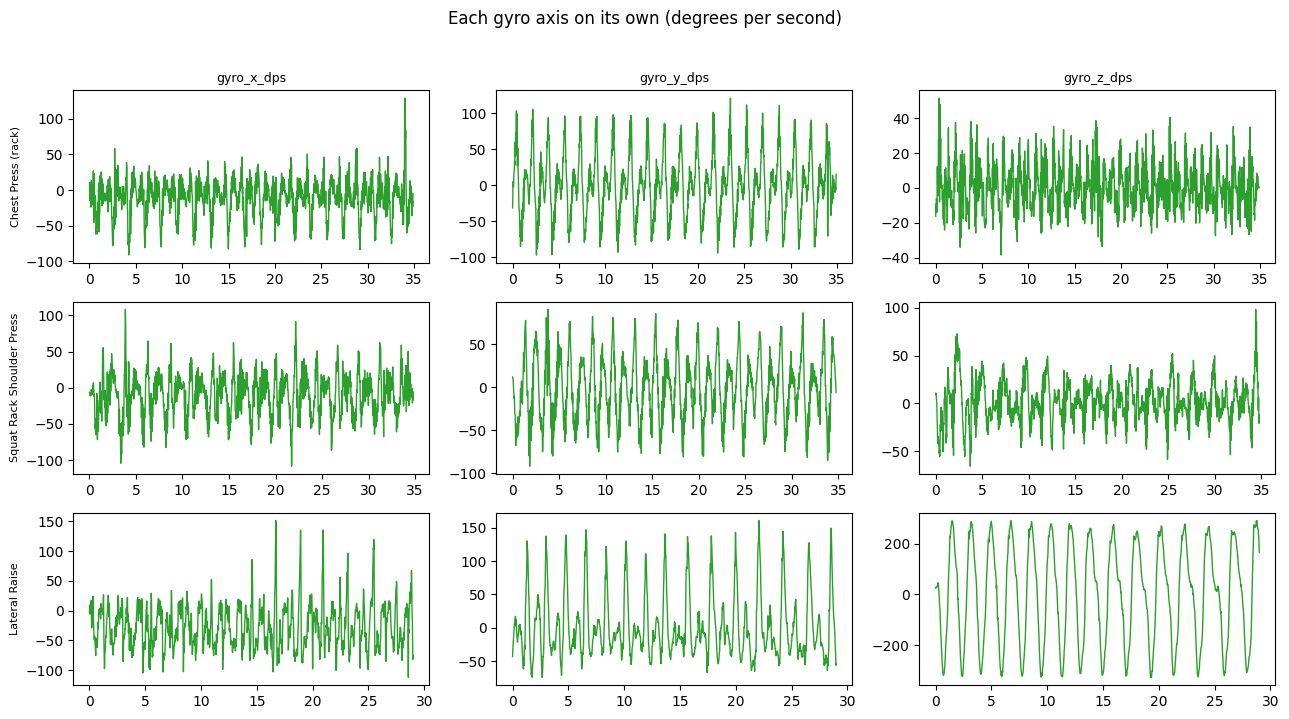

In [5]:
def dominant_axis(sig, cols):
    ranges = {c: sig[c].max() - sig[c].min() for c in cols}
    return max(ranges, key=ranges.get)

fig, axes = plt.subplots(len(EXERCISES), 3, figsize=(13, 7))
for row, ex in enumerate(EXERCISES):
    sig = example_signal[ex]
    t = sig["time_s"].to_numpy() - sig["time_s"].iloc[0]
    for col, axis_col in enumerate(GYR):
        ax = axes[row, col]
        ax.plot(t, sig[axis_col].to_numpy(), linewidth=1, color="tab:green")
        if row == 0:
            ax.set_title(axis_col, fontsize=9)
        if col == 0:
            ax.set_ylabel(ex, fontsize=8)
plt.suptitle("Each gyro axis on its own (degrees per second)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Where does one rep start and end

The dataset doesn't mark rep boundaries, it only tells us the total rep count per
set. So we estimate the boundaries ourselves: smooth the signal, estimate one
rep's rough length from autocorrelation, then find the peaks and troughs at that
spacing.

The axis used in every plot below is the dominant one for that exercise and
signal type, picked automatically the same way as in section 4, not chosen by
hand. We label the bottom to top part of each rep concentric (lifting) and the
top to bottom part eccentric (lowering), and print the actual duration of each
part in seconds, plus the total length of that rep.

One caveat worth keeping in mind: this labeling is anchored to whichever signal
we're plotting. For the accel column that maps well onto lifting and lowering.
For the gyro column, the signal is rotation speed, not position, so its own
peaks and troughs can land at slightly different moments than the accel ones for
the same rep. Treat the gyro timing as a second opinion, not a replacement for
the accel one.

We only show the first few reps of one clean example set per exercise, for
readability. RecoFit's paper notes that some exercises produce more than one peak
per rep, so this simple detector won't be perfect across an entire set, that's
fine, this plot is meant to show the idea clearly, not to be a production rep
counter.

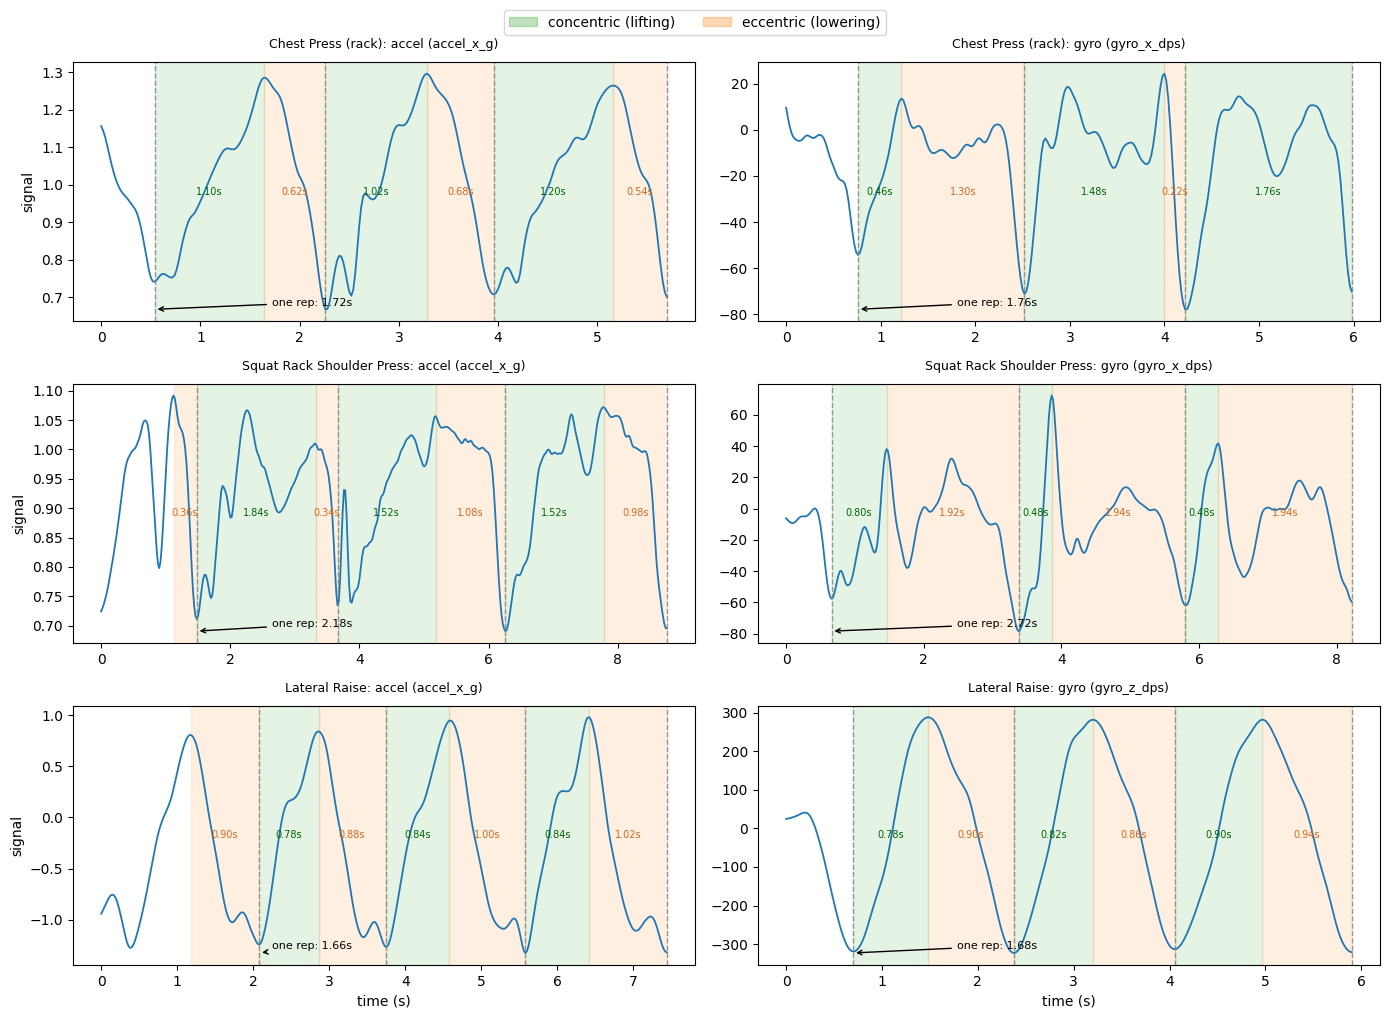

In [6]:
def smooth(y, fs=50.0, cutoff_hz=4.0):
    b, a = butter(2, cutoff_hz / (fs / 2), btype="low")
    return filtfilt(b, a, y)

def estimate_period(y_s, fs=50.0):
    yc = y_s - y_s.mean()
    n = len(yc)
    ac = np.correlate(yc, yc, mode="full")[n - 1:]
    ac = ac / ac[0]
    min_lag = int(0.3 * fs)
    return (np.argmax(ac[min_lag:]) + min_lag) / fs

def find_troughs_peaks(y_s, period_s, fs=50.0):
    distance = max(1, int(0.6 * period_s * fs))
    peaks, _ = find_peaks(y_s, distance=distance, prominence=(y_s.max() - y_s.min()) * 0.2)
    troughs, _ = find_peaks(-y_s, distance=distance, prominence=(y_s.max() - y_s.min()) * 0.2)
    return peaks, troughs

fig, axes = plt.subplots(len(EXERCISES), 2, figsize=(14, 10))
for row, ex in enumerate(EXERCISES):
    sig = example_signal[ex]
    t = sig["time_s"].to_numpy(); t = t - t[0]
    accel_ax = dominant_axis(sig, ACC)
    gyro_ax = dominant_axis(sig, GYR)
    for col, (axis_col, ax_label) in enumerate([(accel_ax, "accel"), (gyro_ax, "gyro")]):
        y = sig[axis_col].to_numpy()
        y_s = smooth(y)
        period_s = estimate_period(y_s)
        peaks, troughs = find_troughs_peaks(y_s, period_s)
        end_idx = troughs[3] if len(troughs) >= 4 else min(len(t) - 1, int(4 * period_s * 50))
        mask = np.arange(len(t)) <= end_idx
        tt, yy = t[mask], y_s[mask]
        pk = peaks[peaks <= end_idx]; tr = troughs[troughs <= end_idx]

        ax = axes[row, col]
        ax.plot(tt, yy, color="tab:blue", linewidth=1.3)
        for tb in tr:
            ax.axvline(t[tb], color="grey", linestyle="--", linewidth=1, alpha=0.8)

        events = sorted(list(tr) + list(pk))
        y_span = yy.max() - yy.min()
        for i in range(len(events) - 1):
            i0, i1 = events[i], events[i + 1]
            is_concentric = i0 in tr
            color = "tab:green" if is_concentric else "tab:orange"
            ax.axvspan(t[i0], t[i1], color=color, alpha=0.12)
            duration = t[i1] - t[i0]
            x_mid = (t[i0] + t[i1]) / 2
            ax.text(x_mid, yy.min() + 0.5 * y_span, f"{duration:.2f}s",
                    ha="center", va="center", fontsize=7,
                    color="darkgreen" if is_concentric else "chocolate")

        if len(tr) >= 2:
            rep_duration = t[tr[1]] - t[tr[0]]
            ax.annotate(f"one rep: {rep_duration:.2f}s", xy=(t[tr[0]], yy.min()), xycoords="data",
                        xytext=(0.32, 0.06), textcoords="axes fraction",
                        arrowprops=dict(arrowstyle="->", color="black"), ha="left", fontsize=8)

        ax.set_title(f"{ex}: {ax_label} ({axis_col})", fontsize=9, pad=10)
        if row == len(EXERCISES) - 1:
            ax.set_xlabel("time (s)")
        if col == 0:
            ax.set_ylabel("signal")

from matplotlib.patches import Patch
handles = [Patch(color="tab:green", alpha=0.3, label="concentric (lifting)"),
           Patch(color="tab:orange", alpha=0.3, label="eccentric (lowering)")]
fig.legend(handles=handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

## 6. Two simple ways to summarize a signal: naive average, and energy

This section computes two different things, and it's worth being clear about how
they differ before looking at the plots.

**Naive baseline.** Just the plain average (mean) of each raw axis over the whole
set. It's the simplest possible number, and it still carries whatever tilt the
sensor happened to have, so two people doing the same exercise with the sensor
worn slightly differently can get different averages for the same movement.

**Energy (RMS).** Root mean square, the square root of the average squared value.
It answers a different question: not "which way did the signal point on average"
but "how much did it move, regardless of direction." RMS also works on signals
that swing above and below zero, like the gyroscope, where a plain average would
mostly cancel out to zero and hide the actual amount of motion.

So the naive baseline can leak information about how the sensor was worn, and RMS
mostly can't. Both go into the final ranking in section 11, so we can see which
one, if either, actually helps tell the exercises apart.

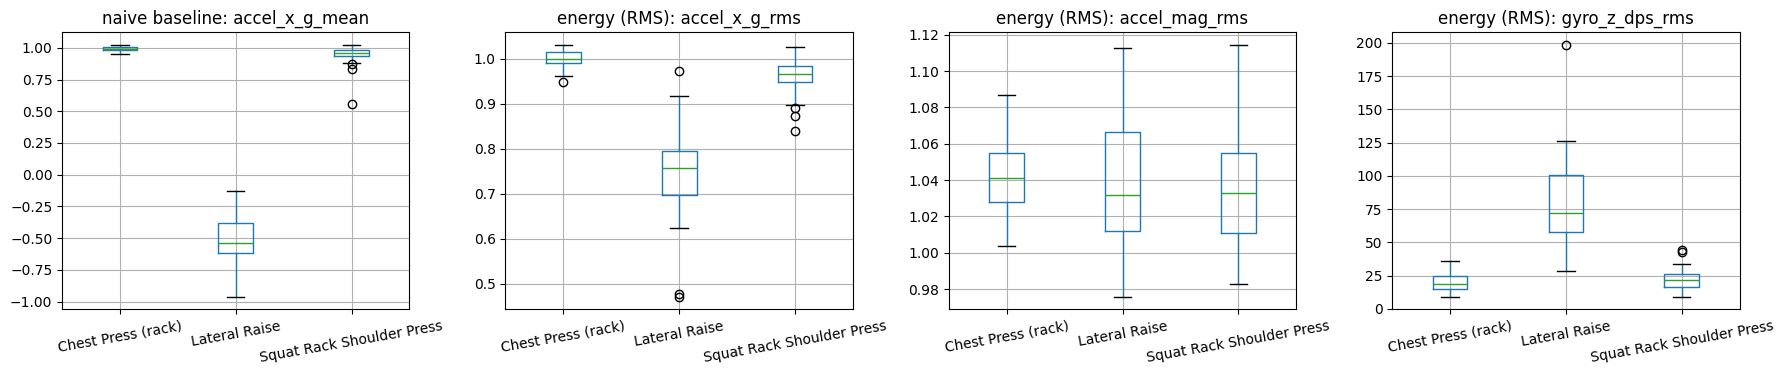

In [7]:
def rms(x):
    return float(np.sqrt(np.mean(np.asarray(x) ** 2)))

def energy_features(record_uid):
    sig = load_signal(record_uid)
    out = {"record_uid": record_uid}
    # naive baseline: plain average per axis
    for c in ACC:
        out[f"{c}_mean"] = sig[c].mean()
    for c in GYR:
        out[f"{c}_std"] = sig[c].std()
    # energy (RMS)
    for c in ACC:
        out[f"{c}_rms"] = rms(sig[c])
    for c in GYR:
        out[f"{c}_rms"] = rms(sig[c])
    out["accel_mag_rms"] = rms(np.sqrt((sig[ACC] ** 2).sum(axis=1)))
    return out

energy_table = pd.concat([
    pd.DataFrame([energy_features(uid) for uid in recordings_by_exercise[ex]["record_uid"]]).assign(exercise=ex)
    for ex in EXERCISES
])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
energy_table.boxplot(column="accel_x_g_mean", by="exercise", ax=axes[0])
axes[0].set_title("naive baseline: accel_x_g_mean"); axes[0].set_xlabel("")
for ax, col in zip(axes[1:], ["accel_x_g_rms", "accel_mag_rms", "gyro_z_dps_rms"]):
    energy_table.boxplot(column=col, by="exercise", ax=ax)
    ax.set_title(f"energy (RMS): {col}"); ax.set_xlabel("")
for ax in axes:
    tidy_xticks(ax)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [8]:
from IPython.display import display

def uid_value_table(df, cols, id_col="record_uid"):
    for col in cols:
        print(f"--- {col} ---")
        display(df[[id_col, col]].reset_index(drop=True))

energy_cols = [c for c in energy_table.columns if c not in ("record_uid", "exercise")]
uid_value_table(energy_table, energy_cols)

energy_table.to_csv(f"{TABLES_DIR}/section6_naive_and_energy_features.csv", index=False)
print(f"saved: {TABLES_DIR}/section6_naive_and_energy_features.csv, shape={energy_table.shape}")

--- accel_x_g_mean ---


,record_uid,accel_x_g_mean
0,singleonly_subject001_Chest_Press_(rack)_record0001,1.003211
1,singleonly_subject001_Chest_Press_(rack)_record0002,0.985553
2,singleonly_subject007_Chest_Press_(rack)_record0001,0.999230
3,singleonly_subject016_Chest_Press_(rack)_record0001,0.978846
4,singleonly_subject017_Chest_Press_(rack)_record0001,0.947812
5,singleonly_subject033_Chest_Press_(rack)_record0001,1.003356
6,singleonly_subject035_Chest_Press_(rack)_record0001,0.979296
7,singleonly_subject052_Chest_Press_(rack)_record0001,1.022964
8,singleonly_subject052_Chest_Press_(rack)_record0002,1.022097
9,singleonly_subject052_Chest_Press_(rack)_record0003,1.022239


--- accel_y_g_mean ---


,record_uid,accel_y_g_mean
0,singleonly_subject001_Chest_Press_(rack)_record0001,-0.007028
1,singleonly_subject001_Chest_Press_(rack)_record0002,0.022483
2,singleonly_subject007_Chest_Press_(rack)_record0001,0.056533
3,singleonly_subject016_Chest_Press_(rack)_record0001,-0.162459
4,singleonly_subject017_Chest_Press_(rack)_record0001,-0.032920
5,singleonly_subject033_Chest_Press_(rack)_record0001,-0.057099
6,singleonly_subject035_Chest_Press_(rack)_record0001,0.256278
7,singleonly_subject052_Chest_Press_(rack)_record0001,-0.142811
8,singleonly_subject052_Chest_Press_(rack)_record0002,-0.067857
9,singleonly_subject052_Chest_Press_(rack)_record0003,-0.057124


--- accel_z_g_mean ---


...

--- gyro_z_dps_rms ---


,record_uid,gyro_z_dps_rms
0,singleonly_subject001_Chest_Press_(rack)_record0001,12.396305
1,singleonly_subject001_Chest_Press_(rack)_record0002,13.359012
2,singleonly_subject007_Chest_Press_(rack)_record0001,9.330429
3,singleonly_subject016_Chest_Press_(rack)_record0001,11.645545
4,singleonly_subject017_Chest_Press_(rack)_record0001,10.247800
5,singleonly_subject033_Chest_Press_(rack)_record0001,16.994057
6,singleonly_subject035_Chest_Press_(rack)_record0001,21.884473
7,singleonly_subject052_Chest_Press_(rack)_record0001,35.564296
8,singleonly_subject052_Chest_Press_(rack)_record0002,36.046247
9,singleonly_subject052_Chest_Press_(rack)_record0003,34.813319


--- accel_mag_rms ---


,record_uid,accel_mag_rms
0,singleonly_subject001_Chest_Press_(rack)_record0001,1.041010
1,singleonly_subject001_Chest_Press_(rack)_record0002,1.030801
2,singleonly_subject007_Chest_Press_(rack)_record0001,1.009467
3,singleonly_subject016_Chest_Press_(rack)_record0001,1.003908
4,singleonly_subject017_Chest_Press_(rack)_record0001,1.016400
5,singleonly_subject033_Chest_Press_(rack)_record0001,1.028619
6,singleonly_subject035_Chest_Press_(rack)_record0001,1.080798
7,singleonly_subject052_Chest_Press_(rack)_record0001,1.080331
8,singleonly_subject052_Chest_Press_(rack)_record0002,1.061382
9,singleonly_subject052_Chest_Press_(rack)_record0003,1.053728


saved: ../outputs/section6_naive_and_energy_features.csv, shape=(99, 15)


## 7. Preprocessing with PCA: picking a signal that doesn't care how the sensor is worn

By "preprocessing" we mean this: before we compute any feature, we first decide
which signal to compute it on. Here's what that looks like for RecoFit's method.

The arm axis (X) is trusted as is, since it always points along the arm no matter
how the band is rotated. The other two axes (Y and Z) are not trustworthy on
their own, so instead of picking one, we combine them with PCA into a single new
signal called `aYZPC1`. The same trick is applied to all three gyro axes to make
`gPC1`.

What PCA is doing, concretely: look at this one recording's Y and Z values
together, and find the one direction, some mix of Y and Z, along which they vary
the most. That direction becomes the new signal. It uses nothing but this single
recording, no exercise labels, no comparison to other recordings. It doesn't
know or care whether it's looking at a bench press or a lateral raise, it just
finds where the movement is.

PCA itself is not a feature. It's a way of choosing a better signal. Energy and
tempo are computed on top of it right after, the same way section 6 computed them
on the naive signal.

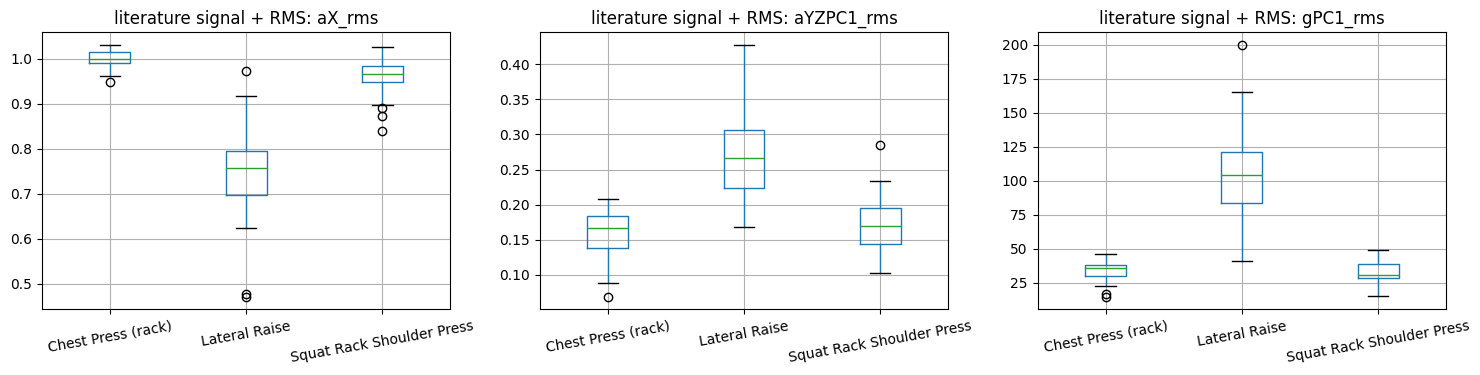

In [9]:
def pca_first_component(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    return Xc @ Vt[0]

def literature_signals(record_uid):
    sig = load_signal(record_uid)
    return {
        "aX": sig["accel_x_g"].to_numpy(),
        "aYZPC1": pca_first_component(sig[["accel_y_g", "accel_z_g"]].to_numpy()),
        "gPC1": pca_first_component(sig[GYR].to_numpy()),
    }

def literature_rms_features(record_uid):
    sigs = literature_signals(record_uid)
    return {"record_uid": record_uid, **{f"{k}_rms": rms(v) for k, v in sigs.items()}}

literature_rms_table = pd.concat([
    pd.DataFrame([literature_rms_features(uid) for uid in recordings_by_exercise[ex]["record_uid"]]).assign(exercise=ex)
    for ex in EXERCISES
])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["aX_rms", "aYZPC1_rms", "gPC1_rms"]):
    literature_rms_table.boxplot(column=col, by="exercise", ax=ax)
    ax.set_title(f"literature signal + RMS: {col}"); ax.set_xlabel("")
    tidy_xticks(ax)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [10]:
lit_cols = [c for c in literature_rms_table.columns if c not in ("record_uid", "exercise")]
uid_value_table(literature_rms_table, lit_cols)

literature_rms_table.to_csv(f"{TABLES_DIR}/section7_pca_orientation_invariant_features.csv", index=False)
print(f"saved: {TABLES_DIR}/section7_pca_orientation_invariant_features.csv, shape={literature_rms_table.shape}")

--- aX_rms ---


,record_uid,aX_rms
0,singleonly_subject001_Chest_Press_(rack)_record0001,1.020689
1,singleonly_subject001_Chest_Press_(rack)_record0002,0.997070
2,singleonly_subject007_Chest_Press_(rack)_record0001,1.000421
3,singleonly_subject016_Chest_Press_(rack)_record0001,0.984934
4,singleonly_subject017_Chest_Press_(rack)_record0001,0.949605
5,singleonly_subject033_Chest_Press_(rack)_record0001,1.015548
6,singleonly_subject035_Chest_Press_(rack)_record0001,0.988206
7,singleonly_subject052_Chest_Press_(rack)_record0001,1.031150
8,singleonly_subject052_Chest_Press_(rack)_record0002,1.030875
9,singleonly_subject052_Chest_Press_(rack)_record0003,1.031075


--- aYZPC1_rms ---


,record_uid,aYZPC1_rms
0,singleonly_subject001_Chest_Press_(rack)_record0001,0.165918
1,singleonly_subject001_Chest_Press_(rack)_record0002,0.160610
2,singleonly_subject007_Chest_Press_(rack)_record0001,0.068592
3,singleonly_subject016_Chest_Press_(rack)_record0001,0.088097
4,singleonly_subject017_Chest_Press_(rack)_record0001,0.171088
5,singleonly_subject033_Chest_Press_(rack)_record0001,0.103510
6,singleonly_subject035_Chest_Press_(rack)_record0001,0.197901
7,singleonly_subject052_Chest_Press_(rack)_record0001,0.195600
8,singleonly_subject052_Chest_Press_(rack)_record0002,0.204898
9,singleonly_subject052_Chest_Press_(rack)_record0003,0.171797


--- gPC1_rms ---


,record_uid,gPC1_rms
0,singleonly_subject001_Chest_Press_(rack)_record0001,45.521989
1,singleonly_subject001_Chest_Press_(rack)_record0002,35.882096
2,singleonly_subject007_Chest_Press_(rack)_record0001,14.560275
3,singleonly_subject016_Chest_Press_(rack)_record0001,25.898063
4,singleonly_subject017_Chest_Press_(rack)_record0001,32.974486
5,singleonly_subject033_Chest_Press_(rack)_record0001,44.068574
6,singleonly_subject035_Chest_Press_(rack)_record0001,43.540933
7,singleonly_subject052_Chest_Press_(rack)_record0001,36.814968
8,singleonly_subject052_Chest_Press_(rack)_record0002,37.226671
9,singleonly_subject052_Chest_Press_(rack)_record0003,35.534108


saved: ../outputs/section7_pca_orientation_invariant_features.csv, shape=(99, 5)


## 8. Preprocessing with gravity: our own addition, not in the RecoFit paper

PCA solves orientation statistically, it just looks for variance and doesn't care
about physical angles. We try something different here: use gravity itself as a
reference, and rotate the signal so "down" means the same thing in every
recording.

Why bother. Without this, the same physical movement can land differently on
x, y, z in two recordings, simply because the sensor rested at a different tilt
each time. A naive feature (section 6) can then partly reflect how the sensor
happened to sit, not what movement actually happened, which is exactly the risk
we've flagged before. Tilt correction tries to remove that before any feature is
computed.

The catch, and we're upfront about it: this data comes from RecoFit's
`singleonly` files, meaning every recording already starts mid exercise, there is
no calm, still moment at the start to calibrate from (we checked, the very first
second is already about as active as the rest of the set). So instead of a real
calibration, we use the average of the whole recording as our best guess at
gravity. That guess turns out to be much better for some exercises than others,
shown right below.

The method: take the average acceleration vector, rotate it so it points straight
down, and apply that same rotation to every sample in the recording. This fixes
two of the three unknown angles (how far forward or backward and side to side the
sensor is tilted). The third, rotation around the now vertical axis, is still
unknown, we have no compass (magnetometer) to resolve it, and we're not
pretending otherwise.

Sanity check: our estimate of gravity should be close to 1.0g if it's trustworthy.
This table shows, per exercise, how close it actually gets:


,mean,std,min,max
exercise,,,,
Chest Press (rack),1.017,0.019,0.990,1.050
Lateral Raise,0.852,0.085,0.672,1.038
Squat Rack Shoulder Press,0.998,0.073,0.634,1.087


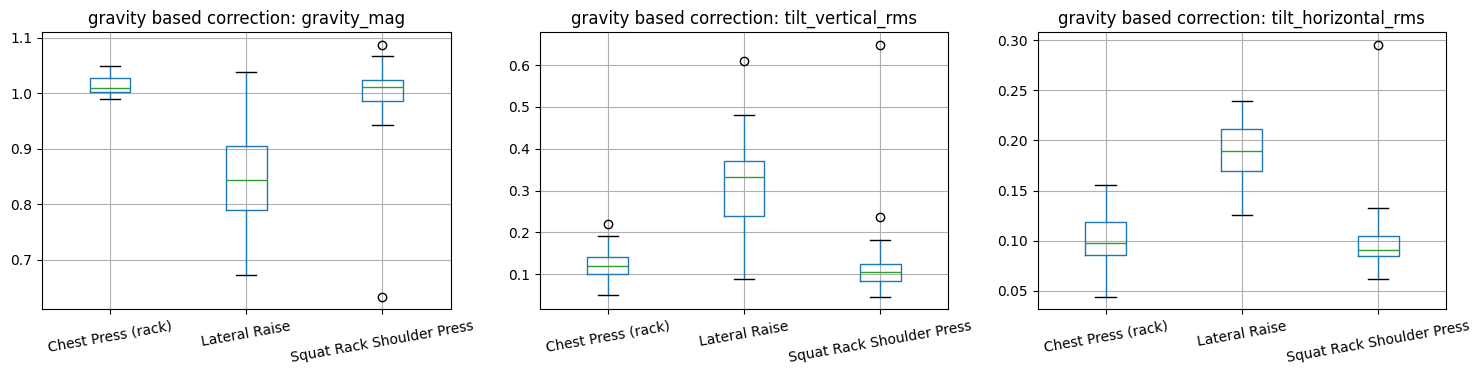

In [11]:
def rotation_to_align(g_hat, target=np.array([0, 0, 1.0])):
    g_hat = g_hat / np.linalg.norm(g_hat)
    v = np.cross(g_hat, target); s = np.linalg.norm(v); c = np.dot(g_hat, target)
    if s < 1e-8:
        return np.eye(3) if c > 0 else -np.eye(3)
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / (s ** 2))

def tilt_correct(record_uid):
    sig = load_signal(record_uid)
    a = sig[ACC].to_numpy()
    g_mean = a.mean(axis=0)
    R = rotation_to_align(g_mean)
    a_rot = a @ R.T
    return a_rot, np.linalg.norm(g_mean)

def tilt_features(record_uid):
    a_rot, gravity_mag = tilt_correct(record_uid)
    vertical = a_rot[:, 2] - a_rot[:, 2].mean()
    horizontal = np.linalg.norm(a_rot[:, :2], axis=1)
    return {"record_uid": record_uid, "gravity_mag": gravity_mag,
            "tilt_vertical_rms": rms(vertical), "tilt_horizontal_rms": rms(horizontal - horizontal.mean())}

tilt_table = pd.concat([
    pd.DataFrame([tilt_features(uid) for uid in recordings_by_exercise[ex]["record_uid"]]).assign(exercise=ex)
    for ex in EXERCISES
])

print("Sanity check: our estimate of gravity should be close to 1.0g if it's trustworthy.")
print("This table shows, per exercise, how close it actually gets:")
display(tilt_table.groupby("exercise")["gravity_mag"].agg(["mean", "std", "min", "max"]).round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["gravity_mag", "tilt_vertical_rms", "tilt_horizontal_rms"]):
    tilt_table.boxplot(column=col, by="exercise", ax=ax)
    ax.set_title(f"gravity based correction: {col}"); ax.set_xlabel("")
    tidy_xticks(ax)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [12]:
tilt_cols = [c for c in tilt_table.columns if c not in ("record_uid", "exercise")]
uid_value_table(tilt_table, tilt_cols)

tilt_table.to_csv(f"{TABLES_DIR}/section8_gravity_tilt_correction_features.csv", index=False)
print(f"saved: {TABLES_DIR}/section8_gravity_tilt_correction_features.csv, shape={tilt_table.shape}")

--- gravity_mag ---


,record_uid,gravity_mag
0,singleonly_subject001_Chest_Press_(rack)_record0001,1.004447
1,singleonly_subject001_Chest_Press_(rack)_record0002,0.996073
2,singleonly_subject007_Chest_Press_(rack)_record0001,1.004948
3,singleonly_subject016_Chest_Press_(rack)_record0001,0.992759
4,singleonly_subject017_Chest_Press_(rack)_record0001,0.998287
5,singleonly_subject033_Chest_Press_(rack)_record0001,1.007920
6,singleonly_subject035_Chest_Press_(rack)_record0001,1.048923
7,singleonly_subject052_Chest_Press_(rack)_record0001,1.049845
8,singleonly_subject052_Chest_Press_(rack)_record0002,1.024551
9,singleonly_subject052_Chest_Press_(rack)_record0003,1.024118


--- tilt_vertical_rms ---


,record_uid,tilt_vertical_rms
0,singleonly_subject001_Chest_Press_(rack)_record0001,0.190594
1,singleonly_subject001_Chest_Press_(rack)_record0002,0.152898
2,singleonly_subject007_Chest_Press_(rack)_record0001,0.049479
3,singleonly_subject016_Chest_Press_(rack)_record0001,0.115390
4,singleonly_subject017_Chest_Press_(rack)_record0001,0.089409
5,singleonly_subject033_Chest_Press_(rack)_record0001,0.158440
6,singleonly_subject035_Chest_Press_(rack)_record0001,0.177470
7,singleonly_subject052_Chest_Press_(rack)_record0001,0.138290
8,singleonly_subject052_Chest_Press_(rack)_record0002,0.134334
9,singleonly_subject052_Chest_Press_(rack)_record0003,0.135287


--- tilt_horizontal_rms ---


,record_uid,tilt_horizontal_rms
0,singleonly_subject001_Chest_Press_(rack)_record0001,0.105402
1,singleonly_subject001_Chest_Press_(rack)_record0002,0.137220
2,singleonly_subject007_Chest_Press_(rack)_record0001,0.044657
3,singleonly_subject016_Chest_Press_(rack)_record0001,0.044186
4,singleonly_subject017_Chest_Press_(rack)_record0001,0.071807
5,singleonly_subject033_Chest_Press_(rack)_record0001,0.067147
6,singleonly_subject035_Chest_Press_(rack)_record0001,0.093215
7,singleonly_subject052_Chest_Press_(rack)_record0001,0.117332
8,singleonly_subject052_Chest_Press_(rack)_record0002,0.155504
9,singleonly_subject052_Chest_Press_(rack)_record0003,0.122692


saved: ../outputs/section8_gravity_tilt_correction_features.csv, shape=(99, 5)


**What the table actually shows.** For Chest Press, the estimate lands
almost exactly on 1.0g and barely varies, this person stays in roughly one
position, so the average is a good stand in for gravity. Shoulder Press is fine
on average but noisier, some sets dip as low as 0.6g. Lateral Raise is the
problem case, it averages around 0.85g and drops as low as 0.67g, because this
exercise swings the arm through a wide arc and never returns to anything close to
a still position, so the whole recording's average is not a good gravity
estimate at all.

Bottom line: this correction works reasonably for small, symmetric movements
like the two presses, and breaks down for a wide swinging movement like lateral
raise.

### 8.1 Is that error actually small or actually large

A magnitude close to 1.0g only tells us the estimate isn't wildly off, it
doesn't tell us how much the estimated direction of "down" actually wobbles,
which is the number that matters since that's what we rotate by. So we test it
directly: split each recording into four equal parts, estimate "down" separately
from the first quarter and the last quarter, and measure the angle between the
two. Gravity itself never moves, so a trustworthy method should give nearly the
same answer both times.

In [13]:
def angle_between(v1, v2):
    v1 = v1 / np.linalg.norm(v1); v2 = v2 / np.linalg.norm(v2)
    c = np.clip(np.dot(v1, v2), -1, 1)
    return np.degrees(np.arccos(c))

def quarter_angle_drift(record_uid):
    sig = load_signal(record_uid)
    a = sig[ACC].to_numpy()
    n = len(a); q = max(1, n // 4)
    g_first, g_last = a[:q].mean(axis=0), a[-q:].mean(axis=0)
    return angle_between(g_first, g_last)

drift_table = pd.concat([
    pd.DataFrame({"record_uid": recordings_by_exercise[ex]["record_uid"],
                  "angle_first_vs_last_quarter_deg": [quarter_angle_drift(uid) for uid in recordings_by_exercise[ex]["record_uid"]]}).assign(exercise=ex)
    for ex in EXERCISES
])

print("How many degrees does our estimated 'down' direction shift within one recording:")
display(drift_table.groupby("exercise")["angle_first_vs_last_quarter_deg"].agg(["mean", "median", "min", "max"]).round(1))
print("\nThe three worst individual sets:")
display(drift_table.sort_values("angle_first_vs_last_quarter_deg", ascending=False).head(3))

How many degrees does our estimated 'down' direction shift within one recording:


,mean,median,min,max
exercise,,,,
Chest Press (rack),4.1,3.7,0.5,8.2
Lateral Raise,11.6,11.2,1.6,27.7
Squat Rack Shoulder Press,7.1,3.4,0.5,102.9



The three worst individual sets:


,record_uid,angle_first_vs_last_quarter_deg,exercise
57,singleonly_subject079_Squat_Rack_Shoulder_Press_record0001,102.874940,Squat Rack Shoulder Press
79,singleonly_subject069_Lateral_Raise_record0001,27.669300,Lateral Raise
88,singleonly_subject077_Lateral_Raise_record0001,23.727648,Lateral Raise


**The real answer.** Chest Press is genuinely stable, about 4 degrees on
average, 8 at worst, small enough to trust. Shoulder Press looks fine on the
typical case (about 3 degrees) but has one set where the estimate is off by 103
degrees, essentially useless for that specific recording, with no way to see it
coming beforehand. Lateral Raise isn't a story of occasional bad luck, it's
consistently off by around 12 degrees, sometimes almost 28.

So a 10 percent error in magnitude was hiding a much rougher reality underneath.
Our recommendation: don't rely on this correction for anything that has to work
reliably. We keep it here because it's a real, honestly tested idea, and it did
add some value in the final ranking (section 11), but PCA remains the safer
default, since it never assumes the sensor was ever still.

## 9. Tempo: how long one rep takes

This is not a claim that any exercise always takes a fixed number of seconds,
that would depend on the person and how they feel that day, and wouldn't be a
useful feature. What we actually measure is simpler: within one set, how long
does this person's own rep take, on average, found by looking for the strongest
repeating pattern in the signal (autocorrelation).

As an absolute number across different people, this can be noisy. But if two
exercises genuinely take different amounts of time because of how the joint
moves (a big shoulder rotation versus a small elbow extension, for example),
tempo can still separate them. We don't assume that, we test it with real
numbers in section 11.

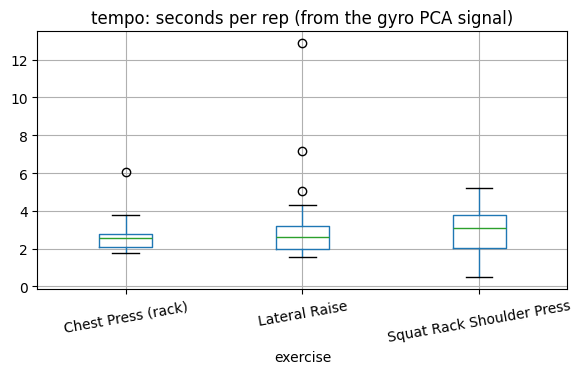

In [14]:
def autocorr_tempo(x, fs=50.0):
    x = np.asarray(x) - np.mean(x)
    n = len(x)
    if n < 20:
        return np.nan
    size = 1
    while size < 2 * n:
        size *= 2
    fx = np.fft.fft(x, size)
    acf = np.fft.ifft(fx * np.conjugate(fx)).real[:n]
    if acf[0] == 0:
        return np.nan
    acf = acf / acf[0]
    min_lag = int(0.5 * fs)  # fixed: was 0.2, too low, matched real rep noise instead of the real period; 0.5 matches the RecoFit paper
    if min_lag >= n - 1:
        return np.nan
    return (np.argmax(acf[min_lag:]) + min_lag) / fs

def tempo_features(record_uid):
    sigs = literature_signals(record_uid)
    return {"record_uid": record_uid, **{f"{k}_tempo_s": autocorr_tempo(v) for k, v in sigs.items()}}

tempo_table = pd.concat([
    pd.DataFrame([tempo_features(uid) for uid in recordings_by_exercise[ex]["record_uid"]]).assign(exercise=ex)
    for ex in EXERCISES
])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
tempo_table.boxplot(column="gPC1_tempo_s", by="exercise", ax=ax)
ax.set_title("tempo: seconds per rep (from the gyro PCA signal)")
tidy_xticks(ax)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [15]:
tempo_cols = [c for c in tempo_table.columns if c not in ("record_uid", "exercise")]
uid_value_table(tempo_table, tempo_cols)

tempo_table.to_csv(f"{TABLES_DIR}/section9_tempo_features.csv", index=False)
print(f"saved: {TABLES_DIR}/section9_tempo_features.csv, shape={tempo_table.shape}")

--- aX_tempo_s ---


,record_uid,aX_tempo_s
0,singleonly_subject001_Chest_Press_(rack)_record0001,1.76
1,singleonly_subject001_Chest_Press_(rack)_record0002,2.06
2,singleonly_subject007_Chest_Press_(rack)_record0001,3.80
3,singleonly_subject016_Chest_Press_(rack)_record0001,2.24
4,singleonly_subject017_Chest_Press_(rack)_record0001,2.52
5,singleonly_subject033_Chest_Press_(rack)_record0001,1.98
6,singleonly_subject035_Chest_Press_(rack)_record0001,1.78
7,singleonly_subject052_Chest_Press_(rack)_record0001,1.94
8,singleonly_subject052_Chest_Press_(rack)_record0002,1.96
9,singleonly_subject052_Chest_Press_(rack)_record0003,1.98


--- aYZPC1_tempo_s ---


,record_uid,aYZPC1_tempo_s
0,singleonly_subject001_Chest_Press_(rack)_record0001,1.76
1,singleonly_subject001_Chest_Press_(rack)_record0002,2.04
2,singleonly_subject007_Chest_Press_(rack)_record0001,3.80
3,singleonly_subject016_Chest_Press_(rack)_record0001,2.28
4,singleonly_subject017_Chest_Press_(rack)_record0001,2.56
5,singleonly_subject033_Chest_Press_(rack)_record0001,2.00
6,singleonly_subject035_Chest_Press_(rack)_record0001,1.78
7,singleonly_subject052_Chest_Press_(rack)_record0001,3.78
8,singleonly_subject052_Chest_Press_(rack)_record0002,2.02
9,singleonly_subject052_Chest_Press_(rack)_record0003,1.96


--- gPC1_tempo_s ---


,record_uid,gPC1_tempo_s
0,singleonly_subject001_Chest_Press_(rack)_record0001,1.76
1,singleonly_subject001_Chest_Press_(rack)_record0002,2.06
2,singleonly_subject007_Chest_Press_(rack)_record0001,3.76
3,singleonly_subject016_Chest_Press_(rack)_record0001,2.28
4,singleonly_subject017_Chest_Press_(rack)_record0001,2.56
5,singleonly_subject033_Chest_Press_(rack)_record0001,2.00
6,singleonly_subject035_Chest_Press_(rack)_record0001,1.76
7,singleonly_subject052_Chest_Press_(rack)_record0001,1.96
8,singleonly_subject052_Chest_Press_(rack)_record0002,1.92
9,singleonly_subject052_Chest_Press_(rack)_record0003,1.96


saved: ../outputs/section9_tempo_features.csv, shape=(99, 5)


## 10. Actually trying to measure distance, and watching it fail

We said earlier that turning acceleration into position would be fabrication.
Here we measure that instead of just asserting it. We take one clean rep,
double integrate it two different ways, and compare.

**Naive.** Acceleration to velocity to position, with nothing else applied.

**ZUPT style.** ZUPT stands for zero velocity update. The idea: if we know for a
fact that velocity was zero at certain moments, for example the very start and
the very end of a rep that returns to roughly the same position, we can force our
velocity estimate back to zero there and remove whatever drift had built up in
between. It's not related to the gravity correction from section 8, it's a
completely separate, much simpler trick applied only to this one rep's own
signal.

This rep lasts 1.72 seconds.
Naive result:    final velocity 3.03 m/s (should be 0), final position 2.06 m (a chest press does not travel that far)
ZUPT-style result: final velocity 0.00 m/s, estimated range of motion 0.69 m (a realistic chest press ROM is about 0.3 to 0.4 m)


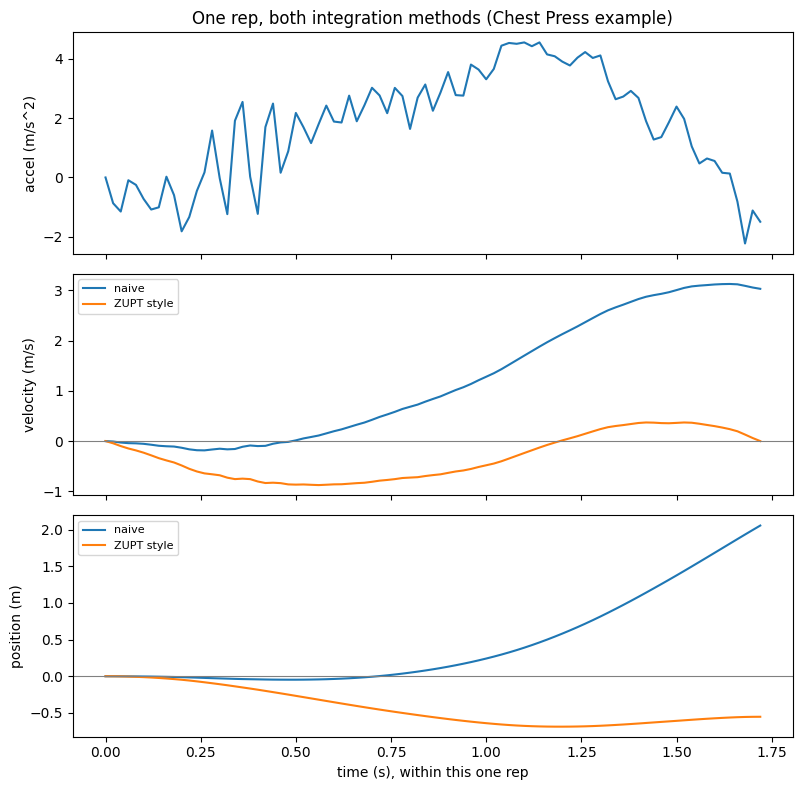

In [16]:
uid_demo = example_uid[BENCH]
sig = load_signal(uid_demo)
t_full = sig["time_s"].to_numpy(); t_full = t_full - t_full[0]
y_full = sig["accel_x_g"].to_numpy()
y_s = smooth(y_full)

troughs, _ = find_peaks(-y_s, distance=int(0.6 * 50), prominence=(y_s.max() - y_s.min()) * 0.2)
i0, i1 = troughs[0], troughs[1]

rep_t = t_full[i0:i1 + 1] - t_full[i0]
rep_a_ms2 = (y_full[i0:i1 + 1] - y_full[i0]) * 9.81  # this rep's own starting value used as its zero point

v_naive = cumulative_trapezoid(rep_a_ms2, rep_t, initial=0)
x_naive = cumulative_trapezoid(v_naive, rep_t, initial=0)

v_lin_drift = np.linspace(v_naive[0], v_naive[-1], len(v_naive))
v_zupt = v_naive - v_lin_drift
x_zupt = cumulative_trapezoid(v_zupt, rep_t, initial=0)

print(f"This rep lasts {rep_t[-1]:.2f} seconds.")
print(f"Naive result:    final velocity {v_naive[-1]:.2f} m/s (should be 0), "
      f"final position {x_naive[-1]:.2f} m (a chest press does not travel that far)")
print(f"ZUPT-style result: final velocity {v_zupt[-1]:.2f} m/s, "
      f"estimated range of motion {x_zupt.max()-x_zupt.min():.2f} m "
      f"(a realistic chest press ROM is about 0.3 to 0.4 m)")

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
axes[0].plot(rep_t, rep_a_ms2); axes[0].set_ylabel("accel (m/s^2)")
axes[0].set_title("One rep, both integration methods (Chest Press example)")
axes[1].plot(rep_t, v_naive, label="naive")
axes[1].plot(rep_t, v_zupt, label="ZUPT style")
axes[1].axhline(0, color="grey", linewidth=0.8); axes[1].set_ylabel("velocity (m/s)"); axes[1].legend(fontsize=8)
axes[2].plot(rep_t, x_naive, label="naive")
axes[2].plot(rep_t, x_zupt, label="ZUPT style")
axes[2].axhline(0, color="grey", linewidth=0.8); axes[2].set_ylabel("position (m)")
axes[2].set_xlabel("time (s), within this one rep"); axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

**What actually happened, in plain terms.** The naive method is the bad
one: over a rep lasting under two seconds, it claims a final speed of about 3
meters per second and a position roughly 2 meters away from the start. Neither
is physically possible for a chest press, this is the failure we expected.

The ZUPT style fix forces the speed back to zero at the end, which removes that
obvious nonsense, but it still estimates a range of motion around 0.7 meters,
close to double a realistic 0.3 to 0.4 meters. So it's better, not good. And it
only works here because we already knew where the rep started and ended, in a
real system finding those boundaries reliably is its own hard problem.

Takeaway: double integration is unreliable even over a single short rep. The
theoretical worry from earlier in this project holds up against real data.

## 11. Every feature, side by side

We now take every feature computed above, for all 99 recordings, and rank them
by how well they separate two specific, hard to tell apart pairs of exercises.

The score is `|median(A) - median(B)| / (IQR(A) + IQR(B))`. A higher score means
the two exercises overlap less on that feature. This is not classifier accuracy,
it's a quick, honest way to see which features are worth carrying into an actual
model later.

Two tables follow. The first ranks features for Chest Press versus Shoulder
Press, the two exercises that look most alike. The second does the same for
Lateral Raise versus Shoulder Press. Same features, same method, two different
comparisons, because a feature that works for one pair might say nothing about
the other.

In [17]:
def sep_score(df, col, ex_a, ex_b):
    a = df.loc[df.exercise == ex_a, col].dropna()
    b = df.loc[df.exercise == ex_b, col].dropna()
    gap = abs(a.median() - b.median())
    spread = (a.quantile(.75) - a.quantile(.25)) + (b.quantile(.75) - b.quantile(.25))
    return gap / spread if spread > 0 else np.nan

all_features = (
    energy_table.merge(literature_rms_table, on=["record_uid", "exercise"])
                .merge(tilt_table, on=["record_uid", "exercise"])
                .merge(tempo_table, on=["record_uid", "exercise"])
)

feature_cols = [c for c in all_features.columns if c not in ("record_uid", "exercise")]

chest_vs_shoulder = pd.DataFrame(
    [{"feature": c, "score": sep_score(all_features, c, BENCH, SHOULDER)} for c in feature_cols]
).sort_values("score", ascending=False).reset_index(drop=True)

lateral_vs_shoulder = pd.DataFrame(
    [{"feature": c, "score": sep_score(all_features, c, LATERAL, SHOULDER)} for c in feature_cols]
).sort_values("score", ascending=False).reset_index(drop=True)

print("Chest Press vs Shoulder Press, ranked by separation score:")
display(chest_vs_shoulder)
print("\nLateral Raise vs Shoulder Press, ranked by separation score:")
display(lateral_vs_shoulder)

Chest Press vs Shoulder Press, ranked by separation score:


,feature,score
0,aX_rms,0.522757
1,accel_x_g_rms,0.522757
2,accel_x_g_mean,0.452634
3,aX_tempo_s,0.400000
4,accel_y_g_rms,0.340811
5,gPC1_rms,0.270268
6,accel_y_g_mean,0.220266
7,gPC1_tempo_s,0.219512
8,tilt_vertical_rms,0.174094
9,gyro_z_dps_std,0.161277



Lateral Raise vs Shoulder Press, ranked by separation score:


,feature,score
0,accel_x_g_mean,5.339208
1,tilt_horizontal_rms,1.600382
2,accel_x_g_rms,1.565789
3,aX_rms,1.565789
4,gPC1_rms,1.515424
5,tilt_vertical_rms,1.318302
6,accel_y_g_rms,1.134772
7,gravity_mag,1.106955
8,gyro_z_dps_rms,0.958417
9,gyro_z_dps_std,0.956381


## 12. What we actually learned

**A bug fix changed this section's numbers.** The tempo function had a bug: it
was allowed to report periods as short as 0.2 seconds, which is faster than any
real rep, so on many recordings it locked onto noise instead of the actual
rep cycle. That has now been fixed (minimum period raised to 0.5 seconds, matching
the original RecoFit paper's own choice), and `gPC1_tempo_s` is no longer the top
feature for Chest Press vs Shoulder Press below. It dropped from 1st place to 8th.
This is worth stating plainly rather than quietly editing the old claim away.

**Chest Press vs Shoulder Press.** The best features now are energy based:
`aX_rms` and the naive `accel_x_g_rms` are tied for first at 0.52, with the naive
`accel_x_g_mean` close behind at 0.45. Tempo on the raw x axis (`aX_tempo_s`,
0.40) also separates these two well, a shoulder press moves through a bigger
joint angle so it genuinely takes longer per rep. The gyro based tempo feature
(`gPC1_tempo_s`) still carries real signal (0.22) but is now a middle of the pack
feature, not the standout it looked like before the fix. Our own tilt correction
features land in the same middle range, real signal, just not the strongest one.

**Lateral Raise vs Shoulder Press.** The naive `accel_x_g_mean` scores highest
here (5.34, far ahead of everything else), but that comes with a warning: it
might just be picking up a difference in how the sensor sits at rest for these
two exercises, not the movement itself. Reassuringly, the orientation invariant
features (`tilt_horizontal_rms`, `aX_rms`, `gPC1_rms`) also score well on this
pair, which suggests the difference is real, not just posture. One nice
surprise: `gravity_mag`, a side effect of the tilt correction check in section
8, turns out to be a useful feature on its own, because Lateral Raise's wide
swing pulls it away from 1g in a way the two presses don't. Tempo barely
separates this pair at all (`gPC1_tempo_s` 0.17, `aYZPC1_tempo_s` 0.02), these
two apparently take a similar amount of time per rep.

**Tempo is not a universally useful feature.** It depends entirely on which
pair of exercises is being compared, and, as this section's own bug fix shows,
on getting the period estimate right in the first place.

**Tilt correction helped a little, and clearly has a limit.** It added a real,
modest signal in the ranking above, but section 8.1 already showed its gravity
estimate can be off by tens of degrees, and fails outright on at least one
recording. PCA remains the safer default for the same reason it always was: it
never assumes the sensor was ever still.

**The drift experiment matched the theory.** Double integration is unusable
without correction, and even the corrected version overstates movement by about
two times.

**One risk to carry forward.** Raw, orientation dependent features like
`accel_x_g_mean` can score well without us knowing whether that's a real movement
difference or just how the sensor happened to sit. A real classifier should test
naive and invariant features side by side, and split train and test by subject,
never by row, so the same person's sets don't leak across both. This is exactly
what notebook 02 does.

**Next step.** This notebook stops at feature ranking and stays a three exercise
comparison, on purpose. The real exercise and rep recognition build, restricted
to Chest Press and Lateral Raise, continues in
`02_ml_pipeline.ipynb`. An intermediate prototype,
`02_exercise_and_rep_recognition.ipynb`, is kept on the `repcognition-legacy`
branch.
